
# CU Boulder, CSCI 3202 - Introduction to Artificial Intelligence 

# Gil Eskayo
# Markov Decision Process with AIMA Python


<br> 

---

This homework uses the aima python github repository. You should have cloned the aima-python folder for previous assignments. If you haven't or if you have deleted it, clone it now:

`git clone https://github.com/aimacode/aima-python.git`

Once you have a copy, you will need to either put your homework directly you will need to either copy the the homework notebook into the aima-data directory (not the folder containing the .ipynb file, but the actual .ipynb file) or you will need to copy the .py files needed by this homework from the aima-data into the folder containing the notebook (the .ipynb file).

For this assignment, you will need the files:

`mdp4e.py`\
`utils4e.py`

Note: You should copy the files from the repository, not move them. If you move the files, they won't be in the repository for your next assignment.

After you do this if the import statement fails, make sure the homework, mdp4e.py and utils4e.py files are in the same directory, then quit the notebook and reopen it from the File menu.  This resets the import path to the current directory.

In [1]:
from mdp4e import *
from utils4e import print_table
import inspect

In this homework, we will be working with Markov Decision Processes and Policy Iteration. We will solve sequential decision problems, initially on paper (for only 2 states) and then using [mdp](https://github.com/aimacode/aima-python/blob/master/mdp.py) module from [aima-python](https://github.com/aimacode/aima-python) repository.

### Problem 1: Solve on paper (15 pts)

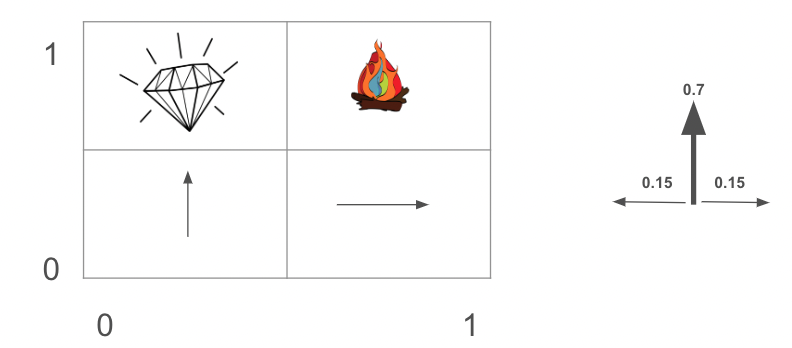

#### If the above diagram, isn't showing up for you in the notebook, please refer to p1.png

In the above diagram, solve for the optimal policy such that max reward is gained.
The grid is a 2x2 map, where:
- Diamond and fire are the terminal states with rewards(+1) and (-1) respectively
- The non-terminal states have arrows in them defining the initial policy for the agent
- All non-terminal states have a living reward of -0.05
- Transitional probabilities in the policy direction would be 0.7, the directions perpendicular to policy direction would be 0.15 (As shown in figure)

The possible actions for the agent at each state would be: UP(^), DOWN(v), LEFT(<) and RIGHT(>)

Find the optimal policy that reaps the max reward from the environment given using policy iteration.

Consider the number of iterations to be 2, for policy evaluation phase using value iteration method. Finally, display the optimal policy obtained, with arrows in your work.

**attach your solutions in the below cell, and add the image in the zip folder**\
LateX is accepted as well.

### Solution:

We begin by labeling the states in the grid:

- **State (0,1):** Diamond $( (+1) )$ — Terminal  
- **State (1,1):** Fire $( (-1) )$ — Terminal  
- **State (0,0):** Non-terminal  
- **State (1,0):** Non-terminal  

The initial policy is defined as follows:  
- At $((0,0))$: **UP** ($(\uparrow)$)  
- At $((1,0))$: **RIGHT** ($(\rightarrow)$)  

All non-terminal states have a living reward of $(-0.05)$.  
Transitional probabilities given the chosen policy action are:
- $(0.7)$ in the chosen (policy) direction,
- $(0.15)$ in each of the perpendicular directions.

Assume the discount factor $(\gamma = 1)$ (undiscounted rewards).

---

### Step 1: Policy Evaluation

We perform **Policy Evaluation** with 2 iterations.

#### **Iteration 1**

1. **For state $((0,0))$ with action $(\uparrow)$ (UP):**

   $$[
   V(0,0) = -0.05 + 0.7 \cdot V(\text{Diamond}) + 0.15 \cdot V(0,0) + 0.15 \cdot V(1,0)
   ]$$
   
   At the start, assume $( V(0,0) = 0 )$ and $( V(1,0) = 0 )$ while $( V(\text{Diamond}) = 1 )$ (since it is terminal). Thus:

   $$[
   V(0,0) = -0.05 + 0.7\cdot 1 + 0.15\cdot 0 + 0.15\cdot 0 = 0.65
   ]$$

2. **For state $((1,0))$ with action $(\rightarrow)$ (RIGHT):**

   $$[
   V(1,0) = -0.05 + 0.7 \cdot V(\text{Fire}) + 0.15 \cdot V(0,0) + 0.15 \cdot V(1,0)
   ]$$
   
   $( V(\text{Fire}) = -1 )$ and the current values $( V(0,0)=0 )$, $( V(1,0)=0 )$. Then:

   $$[
   V(1,0) = -0.05 + 0.7\cdot (-1) + 0.15\cdot 0 + 0.15\cdot 0 = -0.75
   ]$$

After the first iteration:
- $( V(0,0) = 0.65 )$
- $( V(1,0) = -0.75 )$

#### **Iteration 2**

Now we update the values using the results from the first iteration:

1. **For state $((0,0))$:**

   $$[
   V(0,0) = -0.05 + 0.7 \cdot 1 + 0.15 \cdot 0.65 + 0.15 \cdot (-0.75)
   ]$$
   
   Calculation:
   
   $$[
   V(0,0) = -0.05 + 0.7 + 0.0975 - 0.1125 = 0.635
   ]$$

2. **For state $((1,0))$:**

   $$[
   V(1,0) = -0.05 + 0.7\cdot (-1) + 0.15 \cdot 0.65 + 0.15 \cdot (-0.75)
   ]$$
   
   Calculation:
   
   $$[
   V(1,0) = -0.05 - 0.7 + 0.0975 - 0.1125 = -0.765
   ]$$

After two iterations:
- $( V(0,0) = 0.635 )$
- $( V(1,0) = -0.765 )$

---

### Step 2: Policy Improvement

We now improve the policy by checking if changing actions can result in better expected rewards.

#### **State $((0,0))$:**

The current action is **UP** ($(\uparrow)$) with value $(0.635)$.

- **Consider action $(\rightarrow)$ (RIGHT):**

  $$[
  Q(0,0,\rightarrow) = -0.05 + 0.7 \cdot V(1,0) + 0.15 \cdot V(\text{Diamond}) + 0.15 \cdot V(0,0)
  ]$$
  
  Substitute the values:
  
  $$[
  Q(0,0,\rightarrow) = -0.05 + 0.7\cdot (-0.765) + 0.15\cdot 1 + 0.15\cdot 0.635
  ]$$
  
  Calculate step-by-step:
  
  $$[
  Q(0,0,\rightarrow) = -0.05 - 0.5355 + 0.15 + 0.09525 \approx -0.34025
  ]$$
  
Since $( 0.635 > -0.34025 )$, continuing with **UP** remains the best choice.

#### **State $((1,0))$:**

The current action is **RIGHT** ($(\rightarrow)$) with value $(-0.765)$. We now check alternative actions:

- **Consider action $(\uparrow)$ (UP):**

  $$[
  Q(1,0,\uparrow) = -0.05 + 0.7 \cdot V(1,0) + 0.15 \cdot V(\text{Fire}) + 0.15 \cdot V(0,0)
  ]$$
  
  Substitute the values:
  
  $$[
  Q(1,0,\uparrow) = -0.05 + 0.7\cdot (-0.765) + 0.15\cdot (-1) + 0.15\cdot 0.635
  ]$$
  
  Calculation:
  
  $$[
  Q(1,0,\uparrow) = -0.05 - 0.5355 - 0.15 + 0.09525 \approx -0.64025
  ]$$

- **Consider action $(\leftarrow)$ (LEFT):**

  $$[
  Q(1,0,\leftarrow) = -0.05 + 0.7 \cdot V(0,0) + 0.15 \cdot V(1,0) + 0.15 \cdot V(1,0)
  ]$$
  
  Substitute the values:
  
  $$[
  Q(1,0,\leftarrow) = -0.05 + 0.7\cdot 0.635 + 0.15\cdot (-0.765) + 0.15\cdot (-0.765)
  ]$$
  
  Calculation:
  
  $$[
  Q(1,0,\leftarrow) = -0.05 + 0.4445 - 0.11475 - 0.11475 = 0.165
  ]$$

Since $( 0.165 > -0.765 )$ and $( 0.165 > -0.64025 )$, the best action for state $((1,0))$ is to switch to **LEFT** ($(\leftarrow)$).

---

### Final Optimal Policy

After the policy improvement step, the updated optimal actions are:

- **State $((0,0))$:** **UP** $(\ (\uparrow))$
- **State $((1,0))$:** **LEFT** $(\ (\leftarrow))$

Thus, the grid is:

$$[
\begin{array}{|c|c|}
\hline
\text{Diamond } (+1) & \text{Fire } (-1) \\ \hline
\uparrow & \leftarrow \\ \hline
\end{array}
]$$

This is the optimal policy after applying 2 iterations of policy evaluation and a subsequent policy improvement.

---


### Problem 2: Solve through code (25 pts)

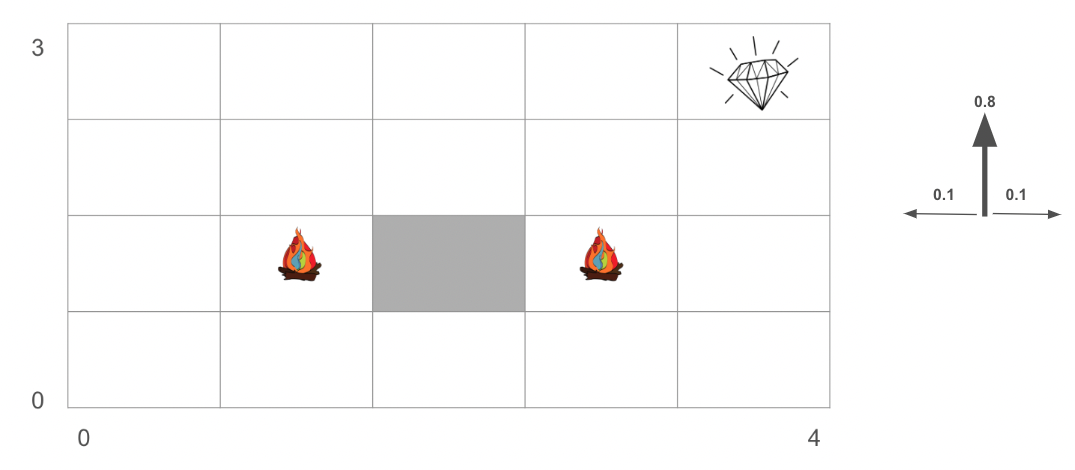

#### If the above diagram, isn't showing up for you in the notebook, please refer to p2.png

**Note: aima-python uses the (column, row) format to denote the squares, thus we will follow the same below.**

In the above diagram, solve for the optimal policy such that max reward is gained.
The grid is a 5X4 map, where:
- Diamond and fire are the terminal states with rewards(+2) and (-2) respectively. 
- All non-terminal states have a living reward of -0.035
- The filled square at (2, 1) denotes a barrier, where it acts like a wall for all its neighboring states (Use `None` in the GridMDP definition)
- Transitional probabilities in the policy direction would be 0.8, the directions perpendicular to policy direction would be 0.1 each (Already hard-coded into GridMDP)

The possible actions for the agent at any state would be: UP(^), DOWN(v), LEFT(<) and RIGHT(>)

Find the optimal policy that reaps the max reward from the environment given using `policy_iteration` method, and display the final policy using the `to_arrows` function from `GridMDP` as shown below. **(5 pts)**

Also, find the optimal policy when the reward at each non-terminal state is:       **(5 pts each)**
- -0.4 
- -4 
- -0.07 

Display the final policy using the `to_arrows` function from `GridMDP` as shown below for each of these.\
Explain briefly how the policy changes and why? **(5 pts)**

In [2]:
inspect.getsourcelines(GridMDP)

(['class GridMDP(MDP):\n',
  '    """A two-dimensional grid MDP, as in [Figure 16.1]. All you have to do is\n',
  '    specify the grid as a list of lists of rewards; use None for an obstacle\n',
  '    (unreachable state). Also, you should specify the terminal states.\n',
  '    An action is an (x, y) unit vector; e.g. (1, 0) means move east."""\n',
  '\n',
  '    def __init__(self, grid, terminals, init=(0, 0), gamma=.9):\n',
  '        grid.reverse()  # because we want row 0 on bottom, not on top\n',
  '        reward = {}\n',
  '        states = set()\n',
  '        self.rows = len(grid)\n',
  '        self.cols = len(grid[0])\n',
  '        self.grid = grid\n',
  '        for x in range(self.cols):\n',
  '            for y in range(self.rows):\n',
  '                if grid[y][x]:\n',
  '                    states.add((x, y))\n',
  '                    reward[(x, y)] = grid[y][x]\n',
  '        self.states = states\n',
  '        actlist = orientations\n',
  '        transitions =

As you can see in the above code snippet defining GridMDP, the transition probabilities are hard-coded into a variable named `T`, with probability 0.8 in the policy direction and probaility 0.1 each in directions perpendicular to the policy direction.

In [3]:
inspect.getsourcelines(policy_iteration)

(['def policy_iteration(mdp):\n',
  '    """Solve an MDP by policy iteration [Figure 17.7]"""\n',
  '\n',
  '    U = {s: 0 for s in mdp.states}\n',
  '    pi = {s: random.choice(mdp.actions(s)) for s in mdp.states}\n',
  '    while True:\n',
  '        U = policy_evaluation(pi, U, mdp)\n',
  '        unchanged = True\n',
  '        for s in mdp.states:\n',
  '            a_star = max(mdp.actions(s), key=lambda a: q_value(mdp, s, a, U))\n',
  '            # a = max(mdp.actions(s), key=lambda a: expected_utility(a, s, U, mdp))\n',
  '            if q_value(mdp, s, a_star, U) > q_value(mdp, s, pi[s], U):\n',
  '                pi[s] = a_star\n',
  '                unchanged = False\n',
  '        if unchanged:\n',
  '            return pi\n'],
 257)

In [4]:
inspect.getsourcelines(policy_evaluation)

(['def policy_evaluation(pi, U, mdp, k=20):\n',
  '    """Return an updated utility mapping U from each state in the MDP to its\n',
  '    utility, using an approximation (modified policy iteration)."""\n',
  '\n',
  '    R, T, gamma = mdp.R, mdp.T, mdp.gamma\n',
  '    for i in range(k):\n',
  '        for s in mdp.states:\n',
  '            U[s] = R(s) + gamma * sum(p * U[s1] for (p, s1) in T(s, pi[s]))\n',
  '    return U\n'],
 275)

#### Example:
Consider the Problem 1, but transition probailities are 0.8 in policy direction , and 0.1 on both sides perpendicular to policy direction (already hard-coded in aima-python GridMDP)

In [13]:
grid = GridMDP([[+1, -1],
                [-0.05, -0.05]],
              terminals=[(0, 1), (1, 1)])

# The first parameter to GridMDP, is a 2-D matrix resembling the given diagram of MDP, 
# it is basically a list of list of rewards of each state in the given MDP.
# Notice the way terminals are denoted, in (column, row) format

#### Solve below:

In [19]:
grid = GridMDP([], terminals=[])

IndexError: list index out of range

In [20]:
pi = policy_iteration()

TypeError: policy_iteration() missing 1 required positional argument: 'mdp'

In [ ]:
import random
from mdp4e import GridMDP, policy_iteration

def get_grid(living_reward):
    grid = [
        # row 3 in final coords
        [living_reward, living_reward, living_reward, living_reward, 2],      # (4,3) is +2 (diamond)
        # row 2
        [living_reward, living_reward, living_reward, living_reward, living_reward],
        # row 1
        [living_reward, living_reward, None,          living_reward, -2],     # (2,1) barrier=None, (4,1) fire=-2
        # row 0
        [living_reward, living_reward, living_reward, living_reward, living_reward]
    ]
    return grid

# Terminal states in (x, y) format
terminals = [(4, 3), (4, 1)]

# Living reward cases
living_rewards = [-0.035, -0.4, -4, -0.07]

for lr in living_rewards:
    # Build the MDP with the specified living reward
    mdp = GridMDP(get_grid(lr), terminals=terminals, gamma=0.9)
    
    # Run policy iteration
    pi = policy_iteration(mdp)
    
    # Convert the final policy to arrow notation
    arrows = mdp.to_arrows(pi)
    
    print(f"Optimal Policy for living reward = {lr}:")
    # Print the grid of arrows row by row (top row first)
    for row in arrows:
        print(row)
    print()


Optimal Policy for living reward = -0.035:
['>', '>', '>', '>', '.']
['>', '>', '>', '^', '^']
['^', '^', None, '^', '.']
['^', '^', '>', '^', '<']

Optimal Policy for living reward = -0.4:
['>', '>', '>', '>', '.']
['>', '>', '>', '^', '^']
['^', '^', None, '^', '.']
['^', '^', '>', '^', '<']

Optimal Policy for living reward = -4:
['>', '>', '>', '>', '.']
['>', '>', '>', '>', '^']
['^', '^', None, '>', '.']
['>', '>', '>', '>', '^']

Optimal Policy for living reward = -0.07:
['>', '>', '>', '>', '.']
['>', '>', '>', '^', '^']
['^', '^', None, '^', '.']
['^', '^', '>', '^', '<']



##### Uncomment the below code snippet to print table denoting the final policy's (pi) actions at all states using arrows.

In [22]:
print_table(mdp.to_arrows(pi))

>   >   >      >   .
>   >   >      ^   ^
^   ^   None   ^   .
^   ^   >      ^   <
